# Put swing 2027 — 10, 30, 90 and 180 days

One contract, four sizes. The same swing over calendar 2027, exercisable on 10, 30, 90 or
180 days out of the year, priced side by side.

**How to use:** edit **§1 Curve** and **§2 Deal**, then Run All. Everything below is output.

The interesting question is how the price per MWh moves with the number of days. A 10-day
swing takes only the very cheapest days, so it buys well below the average forward; a 180-day
swing has to take half the year and converges towards it. That gap is the optionality you are
paying for.

Conventions — signs, units, what `delta` means — are in
[docs/MODEL-CONVENTIONS.md](docs/MODEL-CONVENTIONS.md); the traps are at the bottom.

In [1]:
import time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import storage_model as sm

pd.set_option("display.width", 200, "display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (13, 3.4), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)
# A stale kernel is the classic way to get puzzling results here: `import
# storage_model` is cached, and run_valuation drops params it does not know
# without complaining -- so an old module would silently ignore DISCOUNT_RATE and
# every number would look unchanged. Fail here instead.
# Every name below is called somewhere in this notebook. Listing them all means
# a kernel predating any of them fails here, at the top, rather than part way
# down with an AttributeError once the expensive cells have already run.
import inspect
_missing = [n for n in ("Storage", "run_valuation", "curve_df_for_storage",
                        "quote_row_for_fd_date", "smoothen_curve", "map_curve_to_dates",
                        "month_start", "month_end", "intrinsic_components")
            if not hasattr(sm, n)]
if hasattr(sm, "Storage"):
    if "discount_rate" not in inspect.signature(sm.Storage.__init__).parameters:
        _missing.append("Storage(discount_rate=...)")
    if "delta_pv" not in inspect.getsource(sm.Storage.build):
        _missing.append("Storage.build -> delta_pv")
if _missing:
    raise RuntimeError(
        "This kernel is running an older copy of storage_model — missing "
        + ", ".join(_missing) + ". `import storage_model` is cached, and run_valuation "
        "drops params it does not recognise without complaining, so results below would "
        "be silently wrong or the run would fail half way. Restart the kernel "
        "(Kernel > Restart Kernel and Run All Cells).")

print(f"ready — storage_model from {sm.__file__}")


ready — storage_model from H:\My Drive\Github\dmitry-goryunov\Storage\storage_model.py


## 1. Curve

Three sources, and **the choice of source decides whether `AS_OF` means anything**:

| `CURVE_SOURCE` | what it reads | `AS_OF` |
|---|---|---|
| `"quotes"` | `ttf q.xlsx` — the TTF quote matrix, one row per trading day | selects the row: the last quote on or before this date |
| `"csv"` | `curve.csv` — one stored curve, no quote date attached | **must be `None`**; there is no row to select |
| `"flat"` | nothing — a synthetic curve at `FLAT_LEVEL` for every month | the date the curve starts |

Setting `AS_OF` while the source is `"csv"` now raises instead of being quietly
ignored. The valuation date is not a third knob: it comes out of the curve, because
`VAL_DATE = None` means "value on the day this curve was quoted". Set it explicitly
only to value *after* the quote — never before, which would price a date off a curve
that did not exist yet, and which the library now rejects.

**`"flat"` is the sense-check setting.** A curve with no shape has no day-selection
value, so every number below collapses to something you can predict: `intrinsic` is
exactly 0 with no discount rate, `extrinsic` is exactly 0 with no vol, and a deal
forced to take every day in the window pays exactly `FLAT_LEVEL`. Use it to isolate
one effect at a time — and use it *instead of* editing a row of `ttf q.xlsx` flat,
which changes every other valuation reading that file and cannot be undone from the
spreadsheet.

flat 40 EUR/MWh: 49 contracts, 01 Mar 26 .. Mar 30, 40.00-40.00 EUR/MWh   |   valued 2026-03-06


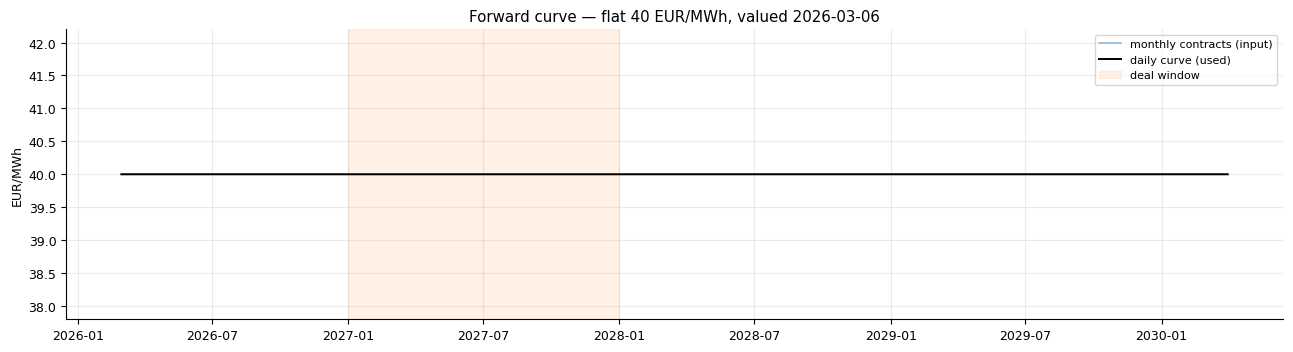

m,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
y,,,,,,,,,,,,
2026,,,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2027,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2028,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2029,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2030,40.00,40.00,40.00,,,,,,,,,


In [2]:
CURVE_SOURCE = "flat"      # "quotes" -> ttf q.xlsx | "csv" -> curve.csv | "flat" -> synthetic
AS_OF        = pd.Timestamp("2026-03-06")   # quote row to price off; "quotes" and "flat"
FLAT_LEVEL   = 40.0                         # "flat" only: one price for every month
VAL_DATE     = None                         # None -> value on the curve's own start date


def load_curve(source=CURVE_SOURCE, as_of=AS_OF, flat_level=FLAT_LEVEL):
    """Return (curve, label, curve_start).

    The start date comes *out* of here rather than in: a curve and the date it is
    valued on are one choice, and letting them be set separately is how you end up
    valuing January off a March quote.
    """
    if source == "flat":
        # A deliberately shapeless curve, for sense checks. Every reported number
        # then has an answer you can state in advance: intrinsic is exactly 0
        # without a rate, extrinsic is exactly 0 without vol, and a deal forced to
        # take every day pays exactly flat_level. It needs no data file, which is
        # the point -- do not flatten a row of `ttf q.xlsx` to get here, because
        # that quietly changes every other valuation that reads the same file.
        if as_of is None:
            raise ValueError("CURVE_SOURCE = 'flat' needs an AS_OF date to start the curve.")
        start = sm.month_start(pd.Timestamp(as_of))
        starts = pd.date_range(start, start + pd.DateOffset(years=4), freq="MS")
        c = pd.DataFrame({"contractStart": starts,
                          "contractEnd": starts.map(sm.month_end),
                          "value": float(flat_level)})
        return c, f"flat {flat_level:g} EUR/MWh", pd.Timestamp(as_of)

    if source == "csv":
        if as_of is not None:
            raise ValueError(
                "AS_OF selects a quote row out of 'ttf q.xlsx'. curve.csv is a single "
                "stored curve with no quote date attached, so AS_OF would do nothing "
                "here. Set CURVE_SOURCE = 'quotes' to price off a date, or AS_OF = None.")
        c = pd.read_csv("curve.csv")
        c["contractStart"] = pd.to_datetime(c["contractStart"], format="mixed")
        c["contractEnd"]   = pd.to_datetime(c["contractEnd"],   format="mixed")
        c = c.sort_values("contractStart").reset_index(drop=True)
        return c, "curve.csv", c["contractStart"].min()

    if source != "quotes":
        raise ValueError(f"CURVE_SOURCE must be 'quotes', 'csv' or 'flat', not {source!r}")
    if as_of is None:
        raise ValueError("CURVE_SOURCE = 'quotes' needs an AS_OF quote date.")

    import re
    q = pd.read_excel("ttf q.xlsx")
    q = q.rename(columns={q.columns[0]: "quote_date"}).dropna(subset=["quote_date"])
    q["quote_date"] = pd.to_datetime(q["quote_date"], format="mixed")
    q = q.sort_values("quote_date").reset_index(drop=True)
    cols = sorted([c for c in q.columns if re.fullmatch(r"TTFc\d+", str(c))],
                  key=lambda c: int(re.search(r"\d+", str(c)).group()))
    row = sm.quote_row_for_fd_date(q, cols, as_of)
    quote_date = pd.Timestamp(row["quote_date"])
    if quote_date != pd.Timestamp(as_of):
        print(f"note: no quote on {pd.Timestamp(as_of):%Y-%m-%d}; using the last one "
              f"before it, {quote_date:%Y-%m-%d}")
    return (sm.curve_df_for_storage(row, cols, curve_start=quote_date, include_da=True),
            f"ttf q.xlsx @ {quote_date:%Y-%m-%d}", quote_date)


CURVE, CURVE_LABEL, CURVE_START = load_curve()
VAL_DATE = CURVE_START if VAL_DATE is None else pd.Timestamp(VAL_DATE)
print(f"{CURVE_LABEL}: {len(CURVE)} contracts, {CURVE['contractStart'].min():%d %b %y} .. "
      f"{CURVE['contractEnd'].max():%b %y}, "
      f"{CURVE['value'].min():.2f}-{CURVE['value'].max():.2f} EUR/MWh"
      f"   |   valued {VAL_DATE:%Y-%m-%d}")

# The curve everything below is priced off. Two things are worth seeing: the
# monthly contracts as given, and the daily curve the model actually uses, which
# is smoothed through the monthly midpoints and then corrected so each month's
# daily average reproduces its contract exactly.
_span  = pd.date_range(CURVE["contractStart"].min(), CURVE["contractEnd"].max(), freq="D")
_daily = sm.smoothen_curve(sm.map_curve_to_dates(_span, CURVE))

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.step(list(CURVE["contractStart"]) + [CURVE["contractEnd"].max()],
        list(CURVE["value"]) + [CURVE["value"].iloc[-1]],
        where="post", color="tab:blue", alpha=.45, lw=1.3, label="monthly contracts (input)")
ax.plot(_daily.index, _daily.values, color="black", lw=1.4, label="daily curve (used)")
ax.axvspan(pd.Timestamp("2027-01-01"), pd.Timestamp("2027-12-31"),
           color="tab:orange", alpha=.10, label="deal window")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Forward curve — {CURVE_LABEL}, valued {VAL_DATE:%Y-%m-%d}")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

_m = CURVE.assign(y=CURVE["contractStart"].dt.year, m=CURVE["contractStart"].dt.strftime("%b"))
_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
display(_m.pivot(index="y", columns="m", values="value")
        .reindex(columns=_order).dropna(axis=1, how="all")
        .style.format("{:.2f}", na_rep="")
        .set_caption("Monthly contracts, EUR/MWh — the input the daily curve is built from"))

## 2. Deal

`DAY_COUNTS` is the list of sizes to compare. Capacity follows from it:
`days x MWH_PER_DAY`.

`PRODUCT_TYPE` is `put_swing` — in this model that is the obligation to **buy** on the
cheapest days. Switch it to `call_swing` for the sell side (the right to sell on the dearest
days); everything below adapts, including the signs.

`DISCOUNT_RATE` is where time value goes: the annual rate at which cash released by the
deal can be redeployed, continuously compounded. It makes a euro on day *i* worth
`exp(-r·i/365.25)` today, so the optimiser stops treating every day as equally good.
**The two sides move in opposite directions** — a seller pulls exercise earlier to get the
cash, a buyer pushes it later to keep it. Leave it at `0.0` to switch time value off.

`STRIKE` is the fixed leg, in EUR/MWh. At `0.0` the deal simply pays (or receives) the
index. Set it and a put swing pays `price - STRIKE` per MWh, a call swing receives
`STRIKE - price`; the `price` column below is that net figure, not the raw index. The
`flat` benchmark is net of it too — a constant per-MWh amount cannot reorder the exercise
days, so benchmarking a strike-net value against a raw forward average would shift
`intrinsic` by the strike while the day-selection spread it measures did not move.

put_swing (buy-side), 2027-01-01 .. 2027-12-31 = 365 days, strike 50.00 EUR/MWh, discounted at 10%
     10 days =   10,000 MWh   ( 2.7% of the window)
     30 days =   30,000 MWh   ( 8.2% of the window)
     90 days =   90,000 MWh   (24.7% of the window)
    180 days =  180,000 MWh   (49.3% of the window)


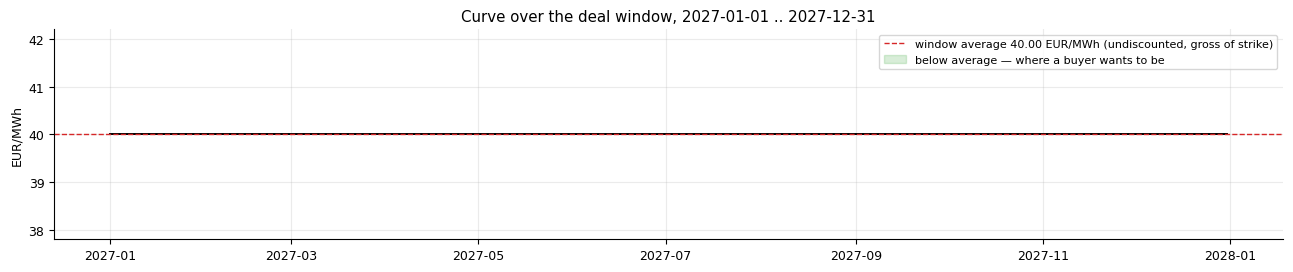

window: min 40.00  mean 40.00  max 40.00 EUR/MWh  (spread 0.00)
the mean above is gross of strike and undiscounted; the `flat` benchmark in the tables below is net of the 50.00 strike and present-valued, at -8.765 EUR/MWh.


In [3]:
PRODUCT_TYPE  = "put_swing"                 # "put_swing" = buy | "call_swing" = sell
START, END    = "2027-01-01", "2027-12-31"
DAY_COUNTS    = [10, 30, 90, 180]
MWH_PER_DAY   = 1_000
STRIKE        = 50.0    # EUR/MWh against the index; 0.0 = pay/receive the index itself

VOL           = 0.50    # annualised
SMR           = 1.0     # mean reversion per year
DISCOUNT_RATE = 0.10    # annual, continuously compounded; 0.0 = no time value
N_P           = 30      # price-tree half-width; checked in section 6
CLIPS_PER_DAY = 1       # exercise is all-or-nothing on a day

WINDOW_DAYS = (pd.Timestamp(END) - pd.Timestamp(START)).days + 1
SIDE = "buy" if PRODUCT_TYPE == "put_swing" else "sell"
print(f"{PRODUCT_TYPE} ({SIDE}-side), {START} .. {END} = {WINDOW_DAYS} days, "
      f"strike {STRIKE:.2f} EUR/MWh, discounted at {DISCOUNT_RATE:.0%}")
for d in DAY_COUNTS:
    print(f"   {d:4d} days = {d * MWH_PER_DAY:>8,} MWh   ({d / WINDOW_DAYS:5.1%} of the window)")

# The slice of that curve the deal actually exercises over.
_win = pd.date_range(START, END, freq="D")
_dc = sm.smoothen_curve(sm.map_curve_to_dates(
    pd.date_range(CURVE["contractStart"].min(), CURVE["contractEnd"].max(), freq="D"), CURVE))
_dw = _dc.reindex(_win)
fig, ax = plt.subplots(figsize=(13, 2.8))
ax.plot(_dw.index, _dw.values, color="black", lw=1.4)
ax.axhline(_dw.mean(), color="tab:red", ls="--", lw=1,
           label=f"window average {_dw.mean():.2f} EUR/MWh (undiscounted, gross of strike)")
ax.fill_between(_dw.index, _dw.values, _dw.mean(), where=_dw.values < _dw.mean(),
                color="tab:green", alpha=.18, label="below average — where a buyer wants to be")
ax.set_ylabel("EUR/MWh"); ax.legend(loc="best", fontsize=8)
ax.set_title(f"Curve over the deal window, {START} .. {END}")
plt.tight_layout(); plt.show()
_pv = float(((_dw.values - STRIKE) * np.exp(-DISCOUNT_RATE *
             np.arange((pd.Timestamp(START) - VAL_DATE).days,
                       (pd.Timestamp(START) - VAL_DATE).days + len(_dw)) / 365.25)).mean())
print(f"window: min {_dw.min():.2f}  mean {_dw.mean():.2f}  max {_dw.max():.2f} EUR/MWh  "
      f"(spread {_dw.max() - _dw.min():.2f})")
print(f"the mean above is gross of strike and undiscounted; the `flat` benchmark in the tables "
      f"below is net of the {STRIKE:.2f} strike and present-valued, at {_pv:.3f} EUR/MWh.")


## 3. Run

Every deal is checked as it is priced:

- **volume** — gross MWh moved, against the capacity asked for
- **invariant** — the reported hedge must reprice the contract,

  `V0 = sum_i DF_i*delta_i*fwd_i - sum_i DF_i*(inj_cost_i*injected_i + wdr_cost_i*withdrawn_i)`

  The cost term matters whenever there is a strike or an injection cost: those are fixed cash
  amounts that do not scale with the price level. Without them the simpler
  `sum(DF*delta*fwd) == V0` only holds for a zero-cost deal.

In [4]:
def price(days, n_p=None, run_intrinsic=True, discount_rate=None):
    params = dict(product_type=PRODUCT_TYPE, valDate=VAL_DATE,
                  storageStart=START, storageEnd=END,
                  capacity_mwh=days * MWH_PER_DAY, daily_max=MWH_PER_DAY,
                  clips_per_day=CLIPS_PER_DAY, vol=VOL, sMR=SMR, strike=STRIKE,
                  discount_rate=DISCOUNT_RATE if discount_rate is None else discount_rate,
                  n_p_full=N_P if n_p is None else n_p, run_intrinsic=run_intrinsic)
    t0 = time.perf_counter()
    s, r = sm.run_valuation(CURVE, params)
    secs = time.perf_counter() - t0

    n  = s.n_t
    dl = np.asarray(s.delta[:n]); df = s.d_curve[:n]
    v0 = float(s.v[0, s.n_p, s.initial_state])
    moved = s.prob[:n] * s.strat[:n] * s.v_step
    injected  = np.clip(moved, 0, None).sum(axis=(1, 2))
    withdrawn = -np.clip(moved, None, 0).sum(axis=(1, 2))
    cash = np.dot(df, np.asarray(s.i_cost)[:n] * injected
                      + np.asarray(s.w_cost)[:n] * withdrawn)
    gross = float(injected.sum() + withdrawn.sum())

    diag = dict(v0=v0, gross_mwh=gross, delta_mwh=float(dl.sum()),
                # Signed by side, not abs(): a strike above the curve flips the
                # value of a put swing positive, and abs() would report a cost
                # where the deal actually pays you.
                price_per_mwh=(-v0 if SIDE == "buy" else v0) / gross if gross else np.nan,
                invariant=abs(float(np.dot(df * dl, s.fwd) - cash) - v0) / max(abs(v0), 1.0),
                starts=s.initial_state, n_states=s.n_states, secs=secs)

    # Split the intrinsic leg. Choosing days is worth two different things once a
    # rate is on: what the schedule saves on price, and what it saves purely by
    # settling later. A flat forward curve is not flat after discounting, so the
    # second is live even with no price shape -- and on a flat curve it is the
    # whole of intrinsic. Needs the deterministic run, which is nearly free.
    if run_intrinsic:
        det, _ = sm.run_valuation(CURVE, {**params, "n_p_full": 0, "run_intrinsic": False})
        # The strike has to reach the split too: both legs it divides out are
        # net of it, so passing the run's strike is not optional.
        try:
            diag["shape"], diag["financing"] = sm.intrinsic_components(det, strike=STRIKE)
        except ValueError:
            # A strike sitting on the curve leaves nothing to divide by -- at
            # K = 40 on a flat 40 the benchmark net of strike is exactly zero.
            # `intrinsic` is still well defined there, and is exactly 0: with no
            # deterministic cash flow on any day there is nothing to defer, so
            # the rate cannot create a financing gain. Only the split is lost.
            diag["shape"] = diag["financing"] = np.nan
    else:
        diag["shape"] = diag["financing"] = np.nan
    return s, r, diag


RUNS = {}
for d in DAY_COUNTS:
    s, r, g = price(d)
    RUNS[d] = (s, r, g)
    print(f"  {d:4d} days   {g['secs']:5.1f}s   {g['gross_mwh']:>9,.0f} MWh "
          f"{SIDE}   {g['price_per_mwh']:7.3f} EUR/MWh   invariant {g['invariant']:.0e}")

    10 days     0.7s      10,000 MWh buy   -12.905 EUR/MWh   invariant 0e+00


    30 days     0.3s      30,000 MWh buy   -12.676 EUR/MWh   invariant 5e-16


    90 days     0.4s      90,000 MWh buy   -11.990 EUR/MWh   invariant 0e+00


   180 days     0.4s     180,000 MWh buy   -10.957 EUR/MWh   invariant 2e-16


## 4. Price against size

`price` is the average price actually paid (or received) per MWh, **net of `STRIKE`**. `flat` is the unweighted
average forward over the window — what you would get with no choice of days. The gap between
them is what the swing is worth.

`intrinsic` splits into **`shape`** and **`financing`**, which sum to it exactly. `shape` is
what the schedule saves on price by picking better days. `financing` is what it saves by
settling on later ones, which is worth something only because `DISCOUNT_RATE` is not zero.
**On a flat curve `shape` is exactly zero and `financing` is the whole of intrinsic** — a
flat forward curve is not flat once discounted, so there is still something to choose. That
is a hurdle-rate gain on deferred cash, not a commodity gain: you realise it by actually
deferring, not by trading anything.

**`intrinsic` here is not an option's intrinsic value.** The moneyness — `F - K`, the 10.00
you would expect from a 40 curve struck at 30 — is the **`flat`** column: what the deal is
worth with no choice of days. `intrinsic` is what choosing days adds on top of that, which
on a flat curve is zero because no day beats any other. And a `put_swing` is an obligation
to buy, not a right: at a zero rate its value is exactly linear in `STRIKE`, no kink at the
money.

**The columns nest — they are not five things to add up.** Reading down:

```
flat                     the benchmark: F - K, with no choice of days
  -  intrinsic           what choosing days is worth on today's forward curve
       =  shape          ... from picking cheaper days
       +  financing      ... from picking later ones (needs DISCOUNT_RATE)
  -  extrinsic           what re-choosing as prices move adds
  =  price               what you actually pay
```

So `flat = price + intrinsic + extrinsic` for a buyer, and `price = flat + intrinsic +
extrinsic` for a seller. `shape` and `financing` are the two halves of `intrinsic`, not
two more terms beside it. `vs flat` is measured off the prices and `total` off the
decomposition, so those two agreeing is a cross-check, not a repeated column.

,MWh,% of window,strike,buy price EUR/MWh,flat EUR/MWh,vs flat,intrinsic,of which shape,of which financing,extrinsic,total,value EUR,delta MWh,invariant
days,,,,,,,,,,,,,,
10,"10,000",2.7%,50.00,-12.905,-8.765,+4.140,0.433,0.000,0.433,3.708,4.140,"129,052","-8,958",0e+00
30,"30,000",8.2%,50.00,-12.676,-8.765,+3.911,0.408,0.000,0.408,3.503,3.911,"380,267","-27,047",5e-16
90,"90,000",24.7%,50.00,-11.990,-8.765,+3.225,0.333,0.000,0.333,2.892,3.225,"1,079,070","-82,681",0e+00
180,"180,000",49.3%,50.00,-10.957,-8.765,+2.192,0.222,0.000,0.222,1.970,2.192,"1,972,250","-170,031",2e-16


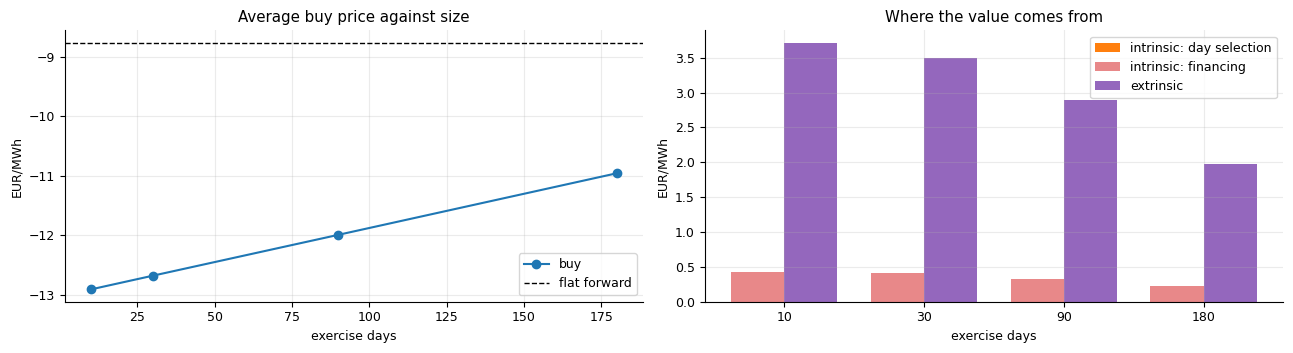

flat = buy price + intrinsic + extrinsic, worst gap 1e-14; intrinsic = shape + financing, worst gap 7e-16
invariant worst case 4.6e-16
inventory: starts at 0 clips of 10 — a put swing starts empty and must fill; a call swing starts full and must empty.


In [5]:
rows = []
for d, (s, r, g) in RUNS.items():
    flat = r["flat_metric"]
    rows.append({
        "days": d,
        "MWh": g["gross_mwh"],
        "% of window": d / WINDOW_DAYS,
        "strike": STRIKE,
        f"{SIDE} price EUR/MWh": g["price_per_mwh"],
        "flat EUR/MWh": flat,
        "vs flat": (flat - g["price_per_mwh"]) if SIDE == "buy" else (g["price_per_mwh"] - flat),
        "intrinsic": r["intrinsic"],
        "of which shape": g["shape"],
        "of which financing": g["financing"],
        "extrinsic": r["extrinsic"],
        "total": r["total"],
        "value EUR": g["v0"],
        "delta MWh": g["delta_mwh"],
        "invariant": g["invariant"],
    })
summary = pd.DataFrame(rows).set_index("days")
display(summary.style.format({
        "MWh": "{:,.0f}", "% of window": "{:.1%}", "strike": "{:.2f}",
        f"{SIDE} price EUR/MWh": "{:.3f}",
        "flat EUR/MWh": "{:.3f}", "vs flat": "{:+.3f}", "intrinsic": "{:.3f}",
        "of which shape": "{:.3f}", "of which financing": "{:.3f}",
        "extrinsic": "{:.3f}", "total": "{:.3f}", "value EUR": "{:,.0f}",
        "delta MWh": "{:,.0f}", "invariant": "{:.0e}"}, na_rep="n/a")
    .set_caption(f"{PRODUCT_TYPE} {START}..{END}, {MWH_PER_DAY:,} MWh/day, strike {STRIKE:.2f}, "
                 f"vol {VOL:.0%}, n_p {N_P} — valued {VAL_DATE:%Y-%m-%d} off {CURVE_LABEL}"))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(summary.index, summary[f"{SIDE} price EUR/MWh"], "o-", color="tab:blue", label=SIDE)
ax[0].axhline(summary["flat EUR/MWh"].iloc[0], color="black", ls="--", lw=1, label="flat forward")
ax[0].set_xlabel("exercise days"); ax[0].set_ylabel("EUR/MWh")
ax[0].set_title(f"Average {SIDE} price against size"); ax[0].legend()

w, _x = 0.38, np.arange(len(summary))
ax[1].bar(_x - w/2, summary["of which shape"], w, label="intrinsic: day selection", color="tab:orange")
ax[1].bar(_x - w/2, summary["of which financing"], w, bottom=summary["of which shape"],
          label="intrinsic: financing", color="tab:red", alpha=.55)
ax[1].bar(_x + w/2, summary["extrinsic"], w, label="extrinsic", color="tab:purple")
ax[1].set_xticks(_x); ax[1].set_xticklabels(summary.index)
ax[1].set_xlabel("exercise days"); ax[1].set_ylabel("EUR/MWh")
ax[1].set_title("Where the value comes from"); ax[1].legend()
plt.tight_layout(); plt.show()

# The columns nest, they do not add up side by side:
#     flat  =  price  +/-  ( intrinsic + extrinsic ),   intrinsic = shape + financing
# `vs flat` is measured off the prices and `total` off the decomposition, so the two
# agreeing is a real cross-check rather than a repeated column.
_gap = (summary["vs flat"] - summary["total"]).abs().max()
_sub = (summary["of which shape"] + summary["of which financing"]
        - summary["intrinsic"]).abs().max()
_scale = max(summary["flat EUR/MWh"].abs().max(), 1.0)
if _gap > 1e-6 * _scale or _sub > 1e-6 * _scale:
    raise AssertionError(
        f"the decomposition does not reconcile with the prices: `vs flat` and `total` "
        f"differ by {_gap:.3e}, shape + financing and intrinsic by {_sub:.3e}. One of "
        f"the reported numbers is wrong — do not read this table.")
print(f"flat = {SIDE} price {'+' if SIDE == 'buy' else '-'} intrinsic "
      f"{'+' if SIDE == 'buy' else '-'} extrinsic, worst gap {_gap:.0e}; "
      f"intrinsic = shape + financing, worst gap {_sub:.0e}")
print(f"invariant worst case {summary['invariant'].max():.1e}")
print(f"inventory: starts at {RUNS[DAY_COUNTS[0]][2]['starts']} clips of "
      f"{RUNS[DAY_COUNTS[0]][2]['n_states']} — a put swing starts empty and must fill; a call "
      f"swing starts full and must empty.")

## 4b. Total P&L

The same deal as a profit-and-loss bridge rather than a per-MWh price, assuming **nothing
was paid for the structure**. Every line is a present value at the valuation date, and they
sum to the model's value exactly.

| line | what it is |
|---|---|
| Premium | what the structure cost. Zero here, so the whole P&L is the deal itself |
| Obligation at the forward | the moneyness, `F - K` per MWh over the whole volume. A put swing must buy, so a strike below the curve is a loss before anything else happens |
| effect of discounting | that obligation is settled during the window, not today |
| Intrinsic | picking cheaper days. Zero on a flat curve |
| NPV cash | interest on cash the schedule has not paid out yet — see §6b |
| Extrinsic | picking days once prices are known, which is the optionality |


,r = 0%,r = 10%
Premium paid for the structure,0,0
"Obligation at the forward (buy, F-K)","100,000","100,000"
effect of discounting it,0,"-12,350"
Intrinsic — day selection,0,0
NPV cash — financing on deferred cash,0,"4,326"
Extrinsic — optionality,"41,809","37,076"
TOTAL P&L (NPV),"141,809","129,052"


lines sum to the model value; residual r = 0% -9e-11, r = 10% -1e-10


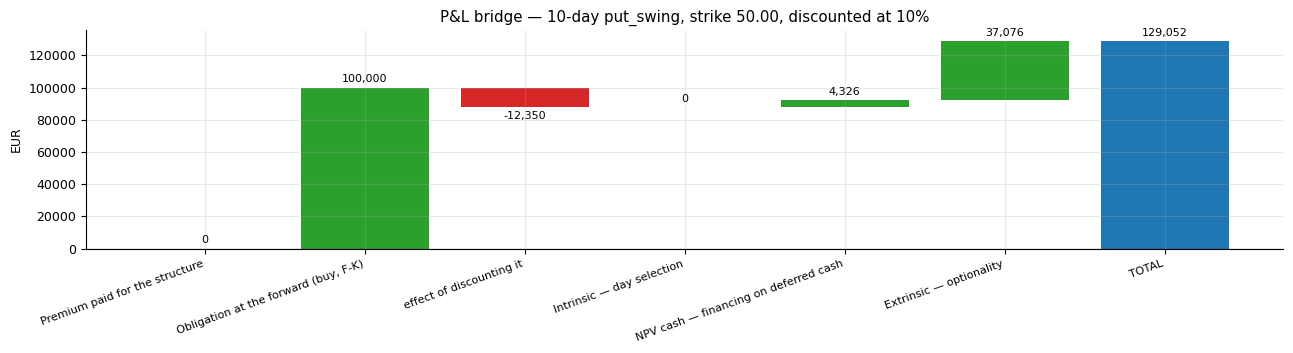

In [6]:
def pnl_bridge(days, rate):
    """Present-value P&L bridge for one deal. Lines sum to the model's value."""
    s, r, g = price(days, discount_rate=rate)
    sgn = -1.0 if SIDE == "buy" else 1.0
    V = g["gross_mwh"]
    win = slice(s.Dt, s._active)
    nominal = sgn * (float(np.mean(np.asarray(s.price_curve, float)[win])) - STRIKE)
    lines = [("Premium paid for the structure",           0.0),
             (f"Obligation at the forward ({SIDE}, F-K)", nominal * V),
             ("  effect of discounting it",               (sgn * r["flat_metric"] - nominal) * V),
             ("Intrinsic — day selection",                g["shape"] * V),
             ("NPV cash — financing on deferred cash",    g["financing"] * V),
             ("Extrinsic — optionality",                  r["extrinsic"] * V)]
    return lines, g["v0"], V


_days = DAY_COUNTS[0]
_cols, _resid = {}, {}
for _rate in (0.0, DISCOUNT_RATE):
    _lines, _v0, _V = pnl_bridge(_days, _rate)
    _cols[f"r = {_rate:.0%}"] = dict(_lines)
    _resid[f"r = {_rate:.0%}"] = sum(v for _, v in _lines) - _v0
    _cols[f"r = {_rate:.0%}"]["TOTAL P&L (NPV)"] = _v0

_pnl = pd.DataFrame(_cols).reindex([l for l, _ in _lines] + ["TOTAL P&L (NPV)"])
display(_pnl.style.format("{:,.0f}")
        .set_caption(f"{_days}-day {PRODUCT_TYPE}, {_V:,.0f} MWh, strike {STRIKE:.2f}, "
                     f"off {CURVE_LABEL} — every line a PV at {VAL_DATE:%Y-%m-%d}")
        .set_properties(subset=pd.IndexSlice["TOTAL P&L (NPV)", :], **{"font-weight": "bold"}))
print("lines sum to the model value; residual " +
      ", ".join(f"{k} {v:.0e}" for k, v in _resid.items()))

# The same thing as a waterfall, at the live rate.
_lines, _v0, _V = pnl_bridge(_days, DISCOUNT_RATE)
_lab = [l.strip() for l, _ in _lines] + ["TOTAL"]
_val = [v for _, v in _lines] + [_v0]
_bottom, _run = [], 0.0
for v in _val[:-1]:
    _bottom.append(_run); _run += v
_bottom.append(0.0)
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.bar(range(len(_val)), _val, bottom=_bottom,
       color=["#999"] + ["tab:red" if v < 0 else "tab:green" for v in _val[1:-1]] + ["tab:blue"])
for i, (b, v) in enumerate(zip(_bottom, _val)):
    ax.text(i, b + v + (2_000 if v >= 0 else -2_000), f"{v:,.0f}",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
ax.axhline(0, color="black", lw=.8)
ax.set_xticks(range(len(_lab)))
ax.set_xticklabels(_lab, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("EUR")
ax.set_title(f"P&L bridge — {_days}-day {PRODUCT_TYPE}, strike {STRIKE:.2f}, "
             f"discounted at {DISCOUNT_RATE:.0%}")
plt.tight_layout(); plt.show()

## 5. When does each size exercise?

Expected MWh per day. The small deal waits for the cheapest days and does nothing else; the
large one has to take most of the year and starts running out of choice.

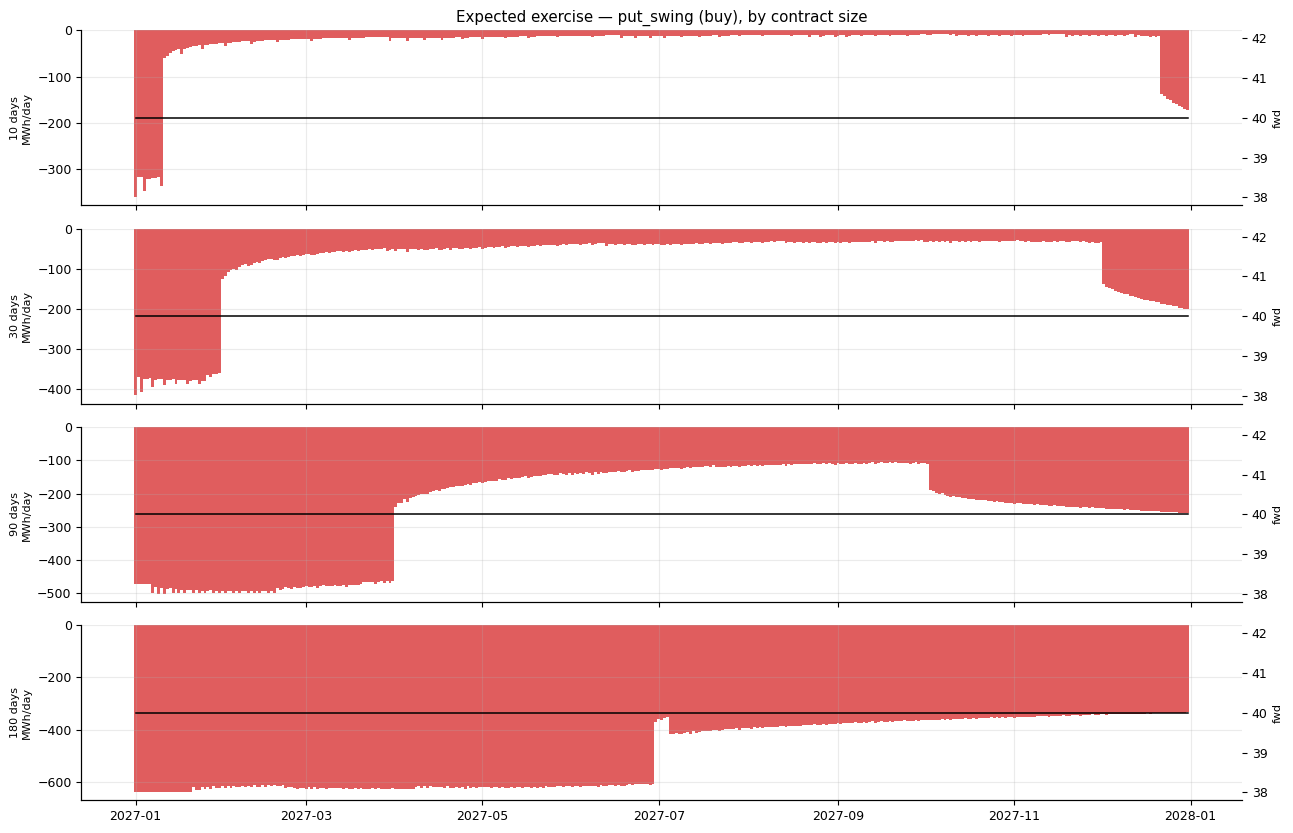

In [7]:
fig, axes = plt.subplots(len(RUNS), 1, figsize=(13, 2.1 * len(RUNS)), sharex=True)
for ax, (d, (s, r, g)) in zip(np.atleast_1d(axes), RUNS.items()):
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    win = slice(s.Dt, s._active)
    ex = pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx).iloc[win]
    px = pd.Series(s.fwd, index=idx).iloc[win]
    ax.bar(ex.index, ex.values, width=1.0,
           color="tab:red" if SIDE == "buy" else "tab:green", alpha=.75)
    ax.set_ylabel(f"{d} days\nMWh/day", fontsize=8)
    twin = ax.twinx(); twin.plot(px.index, px.values, color="black", lw=1.1)
    twin.set_ylabel("fwd", fontsize=8); twin.grid(False)
axes[0].set_title(f"Expected exercise — {PRODUCT_TYPE} ({SIDE}), by contract size")
plt.tight_layout(); plt.show()

## 6b. What the discount rate does

The deal repriced across rates, holding everything else fixed. `mean day` is the
volume-weighted exercise day within the window, so it shows the schedule moving, not just
the value. A buyer defers to keep the cash; a seller accelerates to get it.

Below the table, the same thing as **money rather than a discount factor**. Both schedules
move identical gas at identical prices, so their nominal totals match exactly and only the
timing differs. The gap between them is cash the deal has not paid out yet, and `financing`
is the present value of the interest that balance earns. Realising it means actually having
that money earning `DISCOUNT_RATE` — it is a hurdle-rate gain on your own cash, not
something the gas market pays you.

,buy price EUR/MWh,flat EUR/MWh,intrinsic,extrinsic,value EUR,mean day
rate,,,,,,
0%,-13.951,-10.000,0.000,3.951,"418,518",146
5%,-13.295,-9.361,0.216,3.718,"398,846",141
10%,-12.676,-8.765,0.408,3.503,"380,267",136
20%,-11.536,-7.689,0.725,3.123,"346,093",128


`flat` is PV'd at the same rate, so `intrinsic` stays a like-for-like comparison:
it measures choosing days, not the discounting itself.


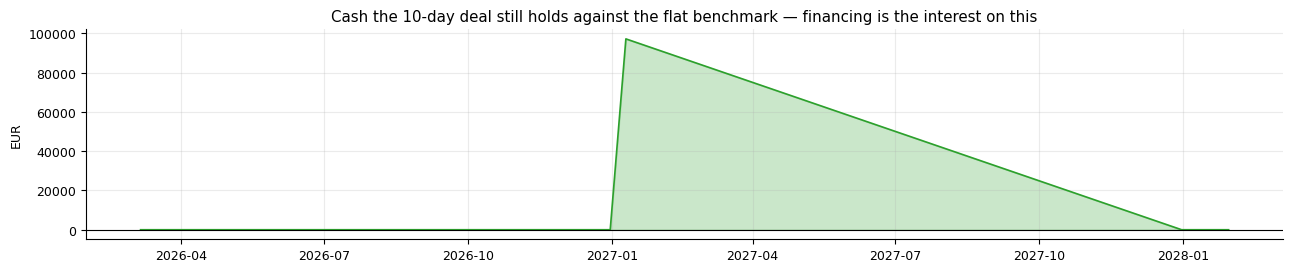

nominal paid, deal    -100,000.00 EUR   benchmark    -100,000.00 EUR   (differ by 0.0e+00)
peak balance            97,260.27 EUR on 10 Jan 2027
PV of interest           4,327.04 EUR  = 0.4327 /MWh
financing reported       4,326.45 EUR  = 0.4326 /MWh   (gap 0.01%)
You receive this only if that balance genuinely earns DISCOUNT_RATE. It is a
hurdle-rate gain on deferred cash, not something the gas market pays you.


In [8]:
rows = []
for rate in (0.0, 0.05, DISCOUNT_RATE, 0.20):
    s, r, g = price(30, discount_rate=rate)
    ex = np.abs(np.asarray(s.exp_ex[:s.n_t]))
    rows.append({"rate": rate,
                 f"{SIDE} price EUR/MWh": g["price_per_mwh"],
                 "flat EUR/MWh": r["flat_metric"],
                 "intrinsic": r["intrinsic"], "extrinsic": r["extrinsic"],
                 "value EUR": g["v0"],
                 "mean day": float(np.dot(np.arange(s.n_t), ex) / ex.sum()) - s.Dt})
rates = pd.DataFrame(rows).set_index("rate")
display(rates.style.format({f"{SIDE} price EUR/MWh": "{:.3f}", "flat EUR/MWh": "{:.3f}",
                            "intrinsic": "{:.3f}", "extrinsic": "{:.3f}",
                            "value EUR": "{:,.0f}", "mean day": "{:.0f}"})
        .format_index("{:.0%}")
        .set_caption(f"30-day deal repriced by discount rate — day 0 is {START}"))
print("`flat` is PV'd at the same rate, so `intrinsic` stays a like-for-like comparison:")
print("it measures choosing days, not the discounting itself.")

# ---- the financing leg as cash you actually hold -------------------------------
# `financing` is not an accounting artefact: it is interest on money the deal has
# not paid out yet. Both schedules move the same gas at the same prices, so their
# nominal totals are identical and only the timing differs. The balance between
# them earns DISCOUNT_RATE, and the PV of that interest is the financing number.
_s, _r, _g = price(DAY_COUNTS[0])
_det, _ = sm.run_valuation(CURVE, dict(
    product_type=PRODUCT_TYPE, valDate=VAL_DATE, storageStart=START, storageEnd=END,
    capacity_mwh=DAY_COUNTS[0] * MWH_PER_DAY, daily_max=MWH_PER_DAY,
    clips_per_day=CLIPS_PER_DAY, vol=VOL, sMR=SMR, strike=STRIKE,
    discount_rate=DISCOUNT_RATE, n_p_full=0, run_intrinsic=False))
_n, _w = _det.n_t, slice(_det.Dt, _det._active)
_net = np.asarray(_det.price_curve, float)[:_n] - STRIKE
_vol = np.abs(np.asarray(_det.exp_ex[:_n]))
_V = _vol.sum()
_cash_deal = _vol * _net
_cash_bench = np.zeros(_n); _cash_bench[_w] = _V / (_det._active - _det.Dt) * _net[_w]
_bal = np.cumsum(_cash_bench - _cash_deal)          # + = money the deal still holds
_pv_int = float(np.dot(_det.d_curve[:_n], DISCOUNT_RATE * _bal / 365.25))
_dates = pd.DatetimeIndex(_det.date_span)[:_n]

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.fill_between(_dates, _bal, 0, color="tab:green", alpha=.25)
ax.plot(_dates, _bal, color="tab:green", lw=1.2)
ax.axhline(0, color="black", lw=.8)
ax.set_ylabel("EUR"); ax.set_title(
    f"Cash the {DAY_COUNTS[0]}-day deal still holds against the flat benchmark "
    f"— financing is the interest on this")
plt.tight_layout(); plt.show()

print(f"nominal paid, deal {_cash_deal.sum():>14,.2f} EUR   benchmark {_cash_bench.sum():>14,.2f} EUR"
      f"   (differ by {abs(_cash_deal.sum() - _cash_bench.sum()):.1e})")
print(f"peak balance       {_bal.max():>14,.2f} EUR on {_dates[int(_bal.argmax())]:%d %b %Y}")
print(f"PV of interest     {_pv_int:>14,.2f} EUR  = {_pv_int / _V:.4f} /MWh")
print(f"financing reported {_g['financing'] * _V:>14,.2f} EUR  = {_g['financing']:.4f} /MWh"
      f"   (gap {abs(_pv_int - _g['financing'] * _V) / max(abs(_pv_int), 1):.2%})")
print("You receive this only if that balance genuinely earns DISCOUNT_RATE. It is a")
print("hurdle-rate gain on deferred cash, not something the gas market pays you.")

## 6. Monthly schedule and hedge

Three different questions, three different numbers. Reading the wrong one is the easiest
mistake this model invites.

| | what it answers | when it is the right column |
|---|---|---|
| **physical** | how much gas do I expect to actually move | procurement, capacity booking, volume planning |
| **forward hedge** | how many MWh of forward immunise the mark | hedging price risk with an OTC forward settling with the deal |
| **futures hedge** | the same, tailed by the discount factor | hedging with margined futures, and PV risk reporting |

They diverge because `delta / physical = E[S | exercise] / F`. In the back months a
mandatory swing is *forced* to exercise on the paths where prices stayed high, so the
price-risk exposure exceeds the volume; in the cheap months, where exercise is chosen, it
falls short. Hedging the back month at its delta over-buys the gas you will physically
need — and hedging it at the physical volume under-hedges the price risk. Both are correct;
pick by the question.

These remain **local** ratios: correct derivatives, but strongly convex, so re-hedge rather
than holding them across a large move.

In [9]:
# Cross-size comparison, on the PHYSICAL requirement.
physical = {}
for d, (s, r, g) in RUNS.items():
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    physical[f"{d} days"] = pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx
                                      ).iloc[s.Dt:s._active].resample("MS").sum()
physical = pd.DataFrame(physical).round(0)
physical.index = physical.index.strftime("%b-%y")
physical.loc["TOTAL"] = physical.sum()
display(physical.style.format("{:,.0f}")
        .set_caption("Expected PHYSICAL volume by month, MWh (negative = buy)"))

# One size broken out three ways, so the divergence is explicit.
BREAKOUT = 10          # which contract size to break out

s, r, g = RUNS[BREAKOUT]
idx = pd.DatetimeIndex(s.date_span[:s.n_t]); win = slice(s.Dt, s._active)
cols = {
    "physical": pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx).iloc[win],
    "forward hedge": pd.Series(np.asarray(s.delta[:s.n_t]), index=idx).iloc[win],
    "futures hedge": pd.Series(np.asarray(s.delta_pv[:s.n_t]), index=idx).iloc[win],
}
brk = pd.DataFrame({k: v.resample("MS").sum() for k, v in cols.items()})
brk["hedge / physical"] = brk["forward hedge"] / brk["physical"]
brk.index = brk.index.strftime("%b-%y")
brk.loc["TOTAL"] = brk.sum()
brk.loc["TOTAL", "hedge / physical"] = (brk.loc["TOTAL", "forward hedge"]
                                        / brk.loc["TOTAL", "physical"])
display(brk.style.format({"physical": "{:,.0f}", "forward hedge": "{:,.0f}",
                          "futures hedge": "{:,.0f}", "hedge / physical": "{:.2f}"})
        .set_caption(f"{BREAKOUT}-day deal: the same month, three questions"))
print("A ratio above 1 means the price exposure exceeds the gas: exercise there is forced")
print("onto high-price paths. Below 1 means exercise is chosen, on cheap days.")

,10 days,30 days,90 days,180 days
Jan-27,"-4,081","-11,482","-15,163","-19,635"
Feb-27,-646,"-2,336","-13,757","-17,335"
Mar-27,-526,"-1,751","-14,678","-19,408"
Apr-27,-501,"-1,524","-5,820","-18,676"
May-27,-428,"-1,353","-4,692","-19,242"
Jun-27,-372,"-1,163","-4,050","-18,181"
Jul-27,-378,"-1,149","-3,745","-12,407"
Aug-27,-329,"-1,041","-3,500","-11,978"
Sep-27,-320,-965,"-3,261","-11,109"
Oct-27,-316,-979,"-6,434","-11,098"


,physical,forward hedge,futures hedge,hedge / physical
Jan-27,"-4,081","-2,860","-2,628",0.70
Feb-27,-646,-519,-472,0.80
Mar-27,-526,-425,-384,0.81
Apr-27,-501,-414,-370,0.83
May-27,-428,-359,-318,0.84
Jun-27,-372,-316,-278,0.85
Jul-27,-378,-329,-287,0.87
Aug-27,-329,-291,-252,0.89
Sep-27,-320,-291,-250,0.91
Oct-27,-316,-295,-251,0.93


A ratio above 1 means the price exposure exceeds the gas: exercise there is forced
onto high-price paths. Below 1 means exercise is chosen, on cheap days.


## 7. Is the tree wide enough?

`n_p` is the price-tree half-width. Too narrow and optionality is silently lost. The 10-day
deal is the most option-like, so it is the most demanding; if it is flat by the `N_P` you
chose, the rest are too.

In [10]:
conv = []
for n_p in (5, 10, 15, 20, 30, 45):
    s, r, g = price(min(DAY_COUNTS), n_p=n_p, run_intrinsic=False)
    conv.append({"n_p": n_p, "EUR/MWh": g["price_per_mwh"], "secs": g["secs"]})
conv = pd.DataFrame(conv).set_index("n_p")
conv["vs n_p=45"] = conv["EUR/MWh"] - conv.loc[45, "EUR/MWh"]
display(conv.style.format({"EUR/MWh": "{:.4f}", "vs n_p=45": "{:+.4f}", "secs": "{:.1f}"})
        .set_caption(f"Tree-width convergence — {min(DAY_COUNTS)}-day deal"))

,EUR/MWh,secs,vs n_p=45
n_p,,,
5,-11.7085,0.2,+1.1966
10,-12.7566,0.2,+0.1485
15,-12.9049,0.2,+0.0002
20,-12.9090,0.2,-0.0039
30,-12.9052,0.2,-0.0001
45,-12.9051,0.2,+0.0000


## Traps worth knowing

- **A curve has a date, and it is not a free parameter.** `AS_OF` picks the quote row;
  the valuation date follows it. The two used to be set separately, so leaving
  `VAL_DATE` behind an `AS_OF` you had moved forward stamped the quote's day-ahead
  price flat across the months in between. Both that and a silently-ignored `AS_OF`
  on the `csv` source now raise.
- **`delta` is not volume.** It is the forward MWh to trade — volume weighted by
  `E[S|exercise]/F` — so it exceeds volume when exercise happens at high prices and falls
  short when it happens at low ones. For a per-MWh price divide value by exercised volume,
  never by `delta`.
- **A put swing must buy.** It is an obligation, not a right: the quota is met on every path,
  which is why the small sizes look so good and the large ones do not. The right-not-obligation
  version is `call_swing` with `zero_penalty=True`.
- **The repricing identity carries a cost term** whenever there is a strike or an injection
  cost — see section 3.
- **The intrinsic split used to break with a strike** — `intrinsic = profiled - flat`
  compared a strike-net value with a raw forward average, so it moved by `K`: down for a
  call, up for a put. Fixed 2026-09-08; `flat_metric` is now reported net of the strike.
- **`exp_ex` is net per day**, which only matters for two-sided deals (storage).
- **The curve must reach one month past the deal** — the model carries a terminal condition
  past the last exercise day.
- **`sVol` and `sMR` are annualised** and their defaults are not calibrated to anything; see
  the calibration note in `docs/MODEL-CONVENTIONS.md`.